# **Import Neccesary Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import train_test_split

print("Libraries Loaded✅")

Libraries Loaded✅


# **Data Exploration**

## *Load the Data*

In [2]:
df = pd.read_csv("C:\\Users\\abhay\\OneDrive\\Desktop\\ML learning\\Logistic Regression\\Loan Default\\Data\\loan_default.csv")
print("Data Loaded👍")

Data Loaded👍


## *Data Exploration*

In [3]:
print(f"The Shape of the dataset is {df.shape}")

The Shape of the dataset is (665, 7)


In [4]:
# First 5 Rows
df.head()

,age,annual_income,loan_amount,credit_score,employment_years,existing_loans,defaulted
0,59.0,46391.0,1110369.0,386.0,8.9,2.0,0
1,49.0,134667.0,1735761.0,400.0,19.9,2.0,0
2,35.0,86830.0,1481124.0,307.0,10.9,4.0,1
3,63.0,57438.0,1066458.0,499.0,NaN,2.0,0
4,28.0,64199.0,1742914.0,NaN,12.1,3.0,0


In [5]:
# Last 5 Rows
df.tail()

,age,annual_income,loan_amount,credit_score,employment_years,existing_loans,defaulted
660,50.0,175435.0,191212.0,431.0,0.4,0.0,0
661,52.0,185748.0,904436.0,559.0,4.6,4.0,0
662,62.0,90183.0,219726.0,700.0,18.0,2.0,0
663,27.0,169764.0,979556.0,525.0,18.4,3.0,0
664,33.0,63143.0,176003.0,501.0,19.6,0.0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665 entries, 0 to 664
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               665 non-null    object 
 1   annual_income     665 non-null    float64
 2   loan_amount       665 non-null    float64
 3   credit_score      645 non-null    float64
 4   employment_years  645 non-null    float64
 5   existing_loans    665 non-null    float64
 6   defaulted         665 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 36.5+ KB


In [7]:
df.describe()

,annual_income,loan_amount,credit_score,employment_years,existing_loans,defaulted
count,665.000000,6.650000e+02,645.000000,645.000000,665.000000,665.000000
mean,109412.276692,1.015635e+06,582.249612,10.311008,2.024060,0.130827
std,52799.652712,5.499283e+05,157.078168,5.812763,1.414009,0.337465
min,-5000.000000,0.000000e+00,300.000000,0.000000,0.000000,0.000000
25%,65376.000000,5.251310e+05,452.000000,5.300000,1.000000,0.000000
50%,111866.000000,1.034448e+06,577.000000,10.800000,2.000000,0.000000
75%,153843.000000,1.481124e+06,717.000000,15.300000,3.000000,0.000000
max,199880.000000,1.991187e+06,1200.000000,20.000000,4.000000,1.000000


In [8]:
# NaN Values
print("The NaN Values in the Dataset is: ")
df.isna().sum()

The NaN Values in the Dataset is: 


age                  0
annual_income        0
loan_amount          0
credit_score        20
employment_years    20
existing_loans       0
defaulted            0
dtype: int64

In [9]:
print(f"The Duplicates in the Data is {df.duplicated().sum()}")

The Duplicates in the Data is 15


# **Data Cleaning**

In [10]:
# Make copy
df_copy = df.copy()

## *Data Type Correction*

In [11]:
df_copy['age'] = pd.to_numeric(df_copy['age'], errors='coerce').astype('Int64')

## *Impossible Values*

In [12]:
df_copy.loc[df_copy['age']<=18,'age'] = np.nan
df_copy.loc[df_copy['age']>100,'age'] = np.nan
df_copy.loc[df_copy['credit_score']>900,'credit_score'] = np.nan
df_copy.loc[df_copy['credit_score']<300,'credit_score'] = np.nan
df_copy.loc[df_copy['annual_income']<30000,'annual_income'] = np.nan

print('Impossible Values Handeled')

Impossible Values Handeled


## *Filling NaN*

In [13]:
print('NaN Values before: ')
print(df_copy.isna().sum())
df_copy['credit_score'] = df_copy['credit_score'].fillna(df_copy['credit_score'].median())
df_copy['age'] = df_copy['age'].fillna(round(df_copy['age'].median(),0))
df_copy['annual_income'] = df_copy['annual_income'].fillna(df_copy['annual_income'].median())
df_copy['employment_years'] = df_copy['employment_years'].fillna(df_copy['employment_years'].median())
print('\nNaN Values after: ')
df_copy.isna().sum()

NaN Values before: 
age                  6
annual_income       56
loan_amount          0
credit_score        21
employment_years    20
existing_loans       0
defaulted            0
dtype: int64

NaN Values after: 


age                 0
annual_income       0
loan_amount         0
credit_score        0
employment_years    0
existing_loans      0
defaulted           0
dtype: int64

## *Duplicates*

In [14]:
df_copy.drop_duplicates(inplace=True)
print('The Duplicates in the dataset after clan is',df_copy.duplicated().sum())

The Duplicates in the dataset after clan is 0


## *Confirm the Dataset*

In [15]:
df_copy.shape
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 650 entries, 0 to 649
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               650 non-null    Int64  
 1   annual_income     650 non-null    float64
 2   loan_amount       650 non-null    float64
 3   credit_score      650 non-null    float64
 4   employment_years  650 non-null    float64
 5   existing_loans    650 non-null    float64
 6   defaulted         650 non-null    int64  
dtypes: Int64(1), float64(5), int64(1)
memory usage: 41.3 KB


# **Data Preperation**

In [17]:
X = df_copy[['age','annual_income','loan_amount','credit_score','employment_years','existing_loans']]
y  = df_copy['defaulted']

print('The Shape of the features is',X.shape)
print('The shape of the output is',y.shape)

The Shape of the features is (650, 6)
The shape of the output is (650,)


In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42)

print(f'Training X size = {X_train.shape}')
print(f'Training y size = {y_train.shape}')
print(f'testing X size = {X_test.shape}')
print(f'testing size = {y_test.shape}')

Training X size = (520, 6)
Training y size = (520,)
testing X size = (130, 6)
testing size = (130,)


# **Model**

## *Train*

In [19]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
print("Model Trained")

Model Trained


## *Test*

In [22]:
# Predict class directly (0 or 1)
y_pred = model.predict(X_test)

# Predict probability (between 0 and 1)
y_prob = model.predict_proba(X_test)[:, 1]
# [:, 1] takes the probability of class 1 (Yes)

# Preview
comparison = pd.DataFrame({
    'Actual':      y_test.values,
    'Predicted':   y_pred,
    'Probability': y_prob.round(3)
})
print(comparison.head(10))

   Actual  Predicted  Probability
0       0          0        0.014
1       0          0        0.009
2       0          0        0.005
3       0          0        0.000
4       0          0        0.000
5       0          0        0.000
6       0          0        0.000
7       1          0        0.220
8       0          0        0.115
9       0          0        0.044


## *Evaluation*

In [23]:
print("Accuracy: ", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1 Score: ", round(f1_score(y_test, y_pred), 4))

Accuracy:  0.9462
Precision: 0.8947
Recall:    0.7727
F1 Score:  0.8293


In [24]:
# Full breakdown in one call
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       108
           1       0.89      0.77      0.83        22

    accuracy                           0.95       130
   macro avg       0.92      0.88      0.90       130
weighted avg       0.94      0.95      0.94       130



## *Confusion Matrix*

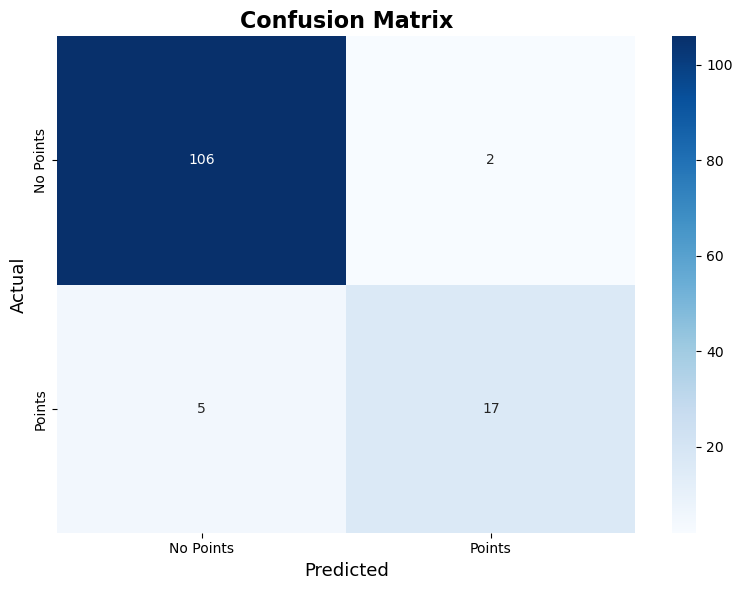

In [28]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## *Coefficent*

In [29]:
print("Feature Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"  {feature:25} → {coef:.4f}")

Feature Coefficients:
  age                       → -0.1058
  annual_income             → -0.0000
  loan_amount               → 0.0000
  credit_score              → -0.0211
  employment_years          → -0.4310
  existing_loans            → 1.5110


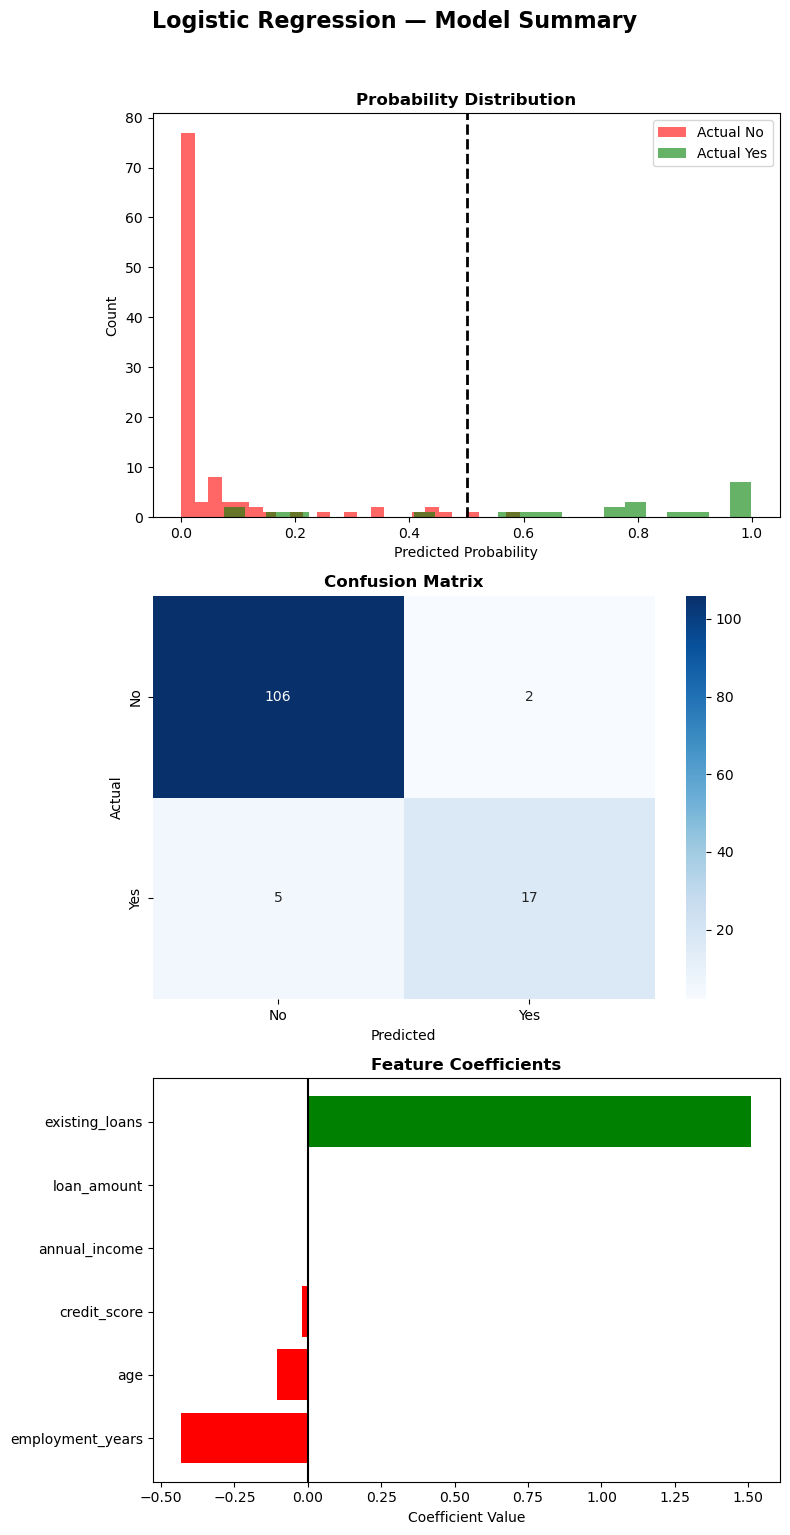

In [33]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

# --- Plot 1: Probability Distribution ---
axes[0].hist(y_prob[y_test == 0], bins=25, alpha=0.6,
             color='red', label='Actual No')
axes[0].hist(y_prob[y_test == 1], bins=25, alpha=0.6,
             color='green', label='Actual Yes')
axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=2)
axes[0].set_title('Probability Distribution', fontweight='bold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Plot 2: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[1].set_title('Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# --- Plot 3: Feature Coefficients ---
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')
colors = ['red' if c < 0 else 'green' for c in coef_df['Coefficient']]
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
axes[2].axvline(x=0, color='black', linewidth=1.5)
axes[2].set_title('Feature Coefficients', fontweight='bold')
axes[2].set_xlabel('Coefficient Value')

plt.suptitle('Logistic Regression — Model Summary', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
